In [1]:
import os
import pandas as pd
import numpy as np
import torch
import logging
import hashlib
import tempfile
import zipfile
import requests
import matplotlib.pyplot as plt
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids


In [2]:
 #for each sigma in [.01,.05,.10,.20,.30], multiply by 256, could be 4 and 30 for now
    # for image in images (by images we mean frame variable as defined below, should be 90 constant frames, each image has 90 frames)
        # for each noise each time we add noise (implement with another for loop, we need 1000 iterations(at first do 100, 200)), 
            #    make sure in range (0,256)
            # for each scan
                # collect prediction output
                # concat. outputs for different scans
            # concat response outputs, collect shape
            # shape should be (1000, 90, number neurons) (call this response_shape), where 90 is number of frames (could be 15 30 etc)
        # concat all the response_shape objects together, shape will be (number of images, 1000, 90, num neurons)
        # calc. sum spike count over 90, shape should be (number images, 1000, number neurons)
        
        # calc. mean over 1000, shape should be (number images, number neurons)
        # calc. var over 1000, shape should be (number images, number neurons)
        # plot mean vs var
        # calc. fano factor var over mean
        # plot fano factor dist. as histogram

In [2]:
def visual_prediction(session, scan_idx, stimuli_noise):
    pred_model, table = scan(session, scan_idx, directory = os.path.join(os.getcwd(), "data","microns")) # look at data/microns/scans.csv for numbers that work
    results = pred_model.predict(stimuli = stimuli_noise)
    results = np.array(results) # should be array regardless
    return results

#### noise and stimuli

In [3]:
frames = concatenate([
    full(shape=[90, 144, 256], dtype="uint8", fill_value=128), # 3 seconds of gray
])

In [4]:
mean = 0
sigma = 5
size = (90,144,256)
noise = np.random.normal(loc = mean, scale = sigma, size = size)

In [5]:
print(f"frames shape: {frames.shape}")
print(f"noise shape: {noise.shape}")

frames shape: (90, 144, 256)
noise shape: (90, 144, 256)


In [5]:
new_frames = (frames+noise).astype("uint8")
print(f"new noise: {new_frames.shape}")

new noise: (90, 144, 256)


#### test prediction

In [8]:
stimuli = new_frames 


In [ ]:
test = visual_prediction(5,6,stimuli)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,8582,8583,8584,8585,8586,8587,8588,8589,8590,8591
0,0.345906,0.081978,0.679314,0.967388,0.465034,0.691159,0.561997,0.533086,0.464637,0.304514,...,1.045534,0.385014,0.172131,1.571597,0.309345,0.897361,0.223569,1.166553,0.199737,0.868112
1,0.322397,0.050524,0.981810,0.826699,0.451769,0.732992,0.672574,0.652038,0.424963,0.399744,...,0.713890,0.478078,0.156199,2.043463,0.550507,1.109957,0.207346,1.334545,0.179315,0.665529
2,0.241023,0.037177,0.939062,0.709085,0.408413,0.625836,0.681490,0.598160,0.362211,0.367521,...,0.710292,0.506192,0.103343,2.500931,0.596308,1.694331,0.271991,1.272391,0.234741,0.611925
3,0.189183,0.024411,0.823971,0.625400,0.400095,0.629049,0.669547,0.603529,0.319186,0.363671,...,0.689184,0.508164,0.116475,2.189878,0.550182,1.593598,0.248470,1.186808,0.215840,0.616409
4,0.190859,0.024800,0.663530,0.562098,0.376396,0.562864,0.686108,0.570416,0.311047,0.346646,...,0.624596,0.562920,0.142873,1.873178,0.543422,1.686866,0.285859,0.918636,0.291959,0.719146


In [31]:
test.shape

(90, 8592)

Note: we want to concat. test for different scans, ie run visual_prediction() with different scans and ids and concat those

In [8]:
sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                  [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]

In [38]:
test1 = visual_prediction(4,7,stimuli)
test2 = visual_prediction(5,6,stimuli)

In [ ]:
print(f"test1 shape: {test1.shape}")
print(f"test2 shape: {test2.shape}")

test1 shape: (90, 7493)
test2 shape: (90, 8592)


#### innermost loop code

In [ ]:
mean = 0
sigma = 5
size = (90,144,256)
noise = np.random.normal(loc = mean, scale = sigma, size = size)

frames = concatenate([
    full(shape=[90, 144, 256], dtype="uint8", fill_value=128), # 3 seconds of gray
])

new_frames = (frames + noise).astype('uint8')

sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                  [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]

# loop takes session scans and iterates through them, concatenating the prediction output for each into one numpy array
for pair in sessions_scans:
    try:
        prediction = visual_prediction(pair[0], pair[1], new_frames)
        final_concat = concatenate((final_concat, prediction), axis = 1)
    except NameError:
        final_concat = visual_prediction(pair[0], pair[1], stimuli)

NameError: name 'stimuli' is not defined

In [10]:
final_concat.shape

(90, 104171)

#### 2nd innermost loop

In [6]:
frames = concatenate([
    full(shape=[90, 144, 256], dtype="uint8", fill_value=128), # 3 seconds of gray
])

Question: how are we deciding mean and sigma for noise?

Need 1000 iterations for each time we add noise, start with 50,100,200. Question here: what does it mean "each time we add noise"? Ie two because we have dynamic and static? 1000 for dynamic and static each?

Question: how to concat. output in different loops, ie should along axis or np.stack? the shape we spoke about tuesday reflects np.stack however not possible due to different shapes for different output

In [5]:
# see question, for now start with 2 iterations of random dynamic guassian noise (50 was too slow)
# runtime for range(2) was 12 minutes
for i in range(2):
    mean = 0
    sigma = 5
    size = (90,144,256)
    noise = np.random.normal(loc = mean, scale = sigma, size = size)
    
    new_frames = (frames + noise).astype('uint8')
    
    stimuli = new_frames 

    sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                    [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]

    for pair in sessions_scans:
        prediction1 = visual_prediction(pair[0], pair[1], stimuli)
        try:
            final_concat1 = concatenate((final_concat1, prediction1), axis = 1)
        except NameError:
            final_concat1 = prediction1
            
    print(f"run {i}, shape of final_concat = {final_concat1.shape}")

    try:
        # ie here concat or np.stack?
        #final_concat2 = concatenate((final_concat2, final_concat1), axis = 1)
        final_concat2 = np.stack([final_concat1, final_concat2], axis = 0)
        print(f"shape of final_concat2 after stack {final_concat2.shape}")
    except NameError:
        final_concat2 = final_concat1    


run 0, shape of final_concat = (90, 320006)


ValueError: all input arrays must have the same shape

In [17]:
final_concat2.shape

(1, 90, 10260)

In [ ]:
final_concat2.shape = (2, 90, 10260)

ValueError: cannot reshape array of size 923400 into shape (2,90,10260)

In [15]:
final_concat2.shape

(1, 90, 10260)

#### final for 2nd innermost loop

In [3]:
frames = concatenate([
    full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
])

# see question in 2nd innermost loop, for now start with 2 iterations of random dynamic guassian noise (50 was too slow)
# runtime for range(2) was 12 minutes
for i in range(2):

    sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                    [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]
    for pair in sessions_scans:
        prediction1 = visual_prediction(pair[0], pair[1], frames) # for now make stimuli frames var., determine if deterministic
        try:
            # ie here concat or np.stack?
            final_concat1 = concatenate((final_concat1, prediction1), axis = 1)
        except NameError:
            final_concat1 = prediction1
    

    try:
        # ie here concat or np.stack?
        final_concat2 = np.stack((final_concat1, final_concat2), axis = 0)
    except NameError:
        final_concat2 = final_concat1
    #except ValueError:
     #   print(f"shape of final_concat1 is {final_concat1.shape}, and final_concat2 is {final_concat2.shape}")
    print(f"Shape of final_concat is {final_concat2.shape} at run {i} after stack")
    del final_concat1    

Shape of final_concat is (15, 104171) at run 0 after stack
Shape of final_concat is (2, 15, 104171) at run 1 after stack


In [4]:
mean1 = final_concat2[0]
mean2 = final_concat2[1]

In [8]:
def summarize(array):
    print(f"Mean: {np.mean(array)}, Min: {np.min(array)}, Max: {np.max(array)}, Var: {np.var(array)}")


In [10]:
print("summary for 1")
summarize(mean1)

summary for 1
Mean: 0.540829598903656, Min: 0.00557289645075798, Max: 43.014339447021484, Var: 0.3560962378978729


Note that without any noise added, this is how we describe the predictions. 

EDA with this new array, with constant noise is it deterministic? To be clear, in this instance we added frames twice (no noise) so both of the (15,5130) arrays should be the same here

#### Deterministic?

In [4]:
final_concat2.shape

(2, 15, 104171)

In [5]:
type(final_concat2)

numpy.ndarray

In [6]:
final_concat2_1 = final_concat2[0,:,:]
print(f"shape of first array: {final_concat2_1.shape}")

shape of first array: (15, 104171)


In [7]:
final_concat2_2 = final_concat2[1,:,:]
print(f"shape of second array: {final_concat2_2.shape}")

shape of second array: (15, 104171)


In [8]:
np.unique(final_concat2_1 == final_concat2_1, return_counts = True)

(array([ True]), array([1562565]))

The above line of code certifies the model is deterministic, as both outputs arrays are exactly the same for the two instances we ran it with no added noise.

#### Now compare two solutions WITH gaussian noise std = 4, mean = 0

In [ ]:
frames = concatenate([
    full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
])

# see question in 2nd innermost loop, for now start with 2 iterations of random dynamic guassian noise (50 was too slow)
# runtime for range(2) was 12 minutes
for i in range(2): # two noise seeds
    mean = 0
    sigma = 4
    size = (15,144,256) # changing to 500 milliseconds of noise (15 frames)
    noise = np.random.normal(loc = mean, scale = sigma, size = size)
    
    new_frames = (frames + noise).astype('uint8')
    
    stimuli = new_frames 

    sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                    [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]

    for pair in sessions_scans:
        prediction1_std4 = visual_prediction(pair[0], pair[1], stimuli) 
        try:
            # ie here concat or np.stack?
            final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
        except NameError:
            final_concat1_std4 = prediction1_std4
    

    try:
        # ie here concat or np.stack?
        final_concat2_std4 = np.stack((final_concat2_std4, final_concat1_std4), axis = 0)
    except NameError:
        final_concat2_std4 = final_concat1_std4
    print(f"Shape of final_concat is {final_concat2_std4.shape} at run {i}")
    del final_concat1_std4    

Shape of final_concat is (15, 104171) at run 0
Shape of final_concat is (2, 15, 104171) at run 1


In [5]:
solution1_std4 = final_concat2_std4[0]
solution2_std4 = final_concat2_std4[1]
print("shape for first solution ",solution1_std4.shape)
print("shape for second solution ", solution2_std4.shape)

shape for first solution  (15, 104171)
shape for second solution  (15, 104171)


In [7]:
tf_solution = np.unique(solution1_std4 == solution2_std4, return_counts = True)
print("confirming we have two different solutions as two different noise instances were added. ", tf_solution)

confirming we have two different solutions as two different noise instances were added.  (array([False,  True]), array([1562531,      34]))


C:\Users\joshf\AppData\Local\Temp\ipykernel_54076\1461384594.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\joshf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


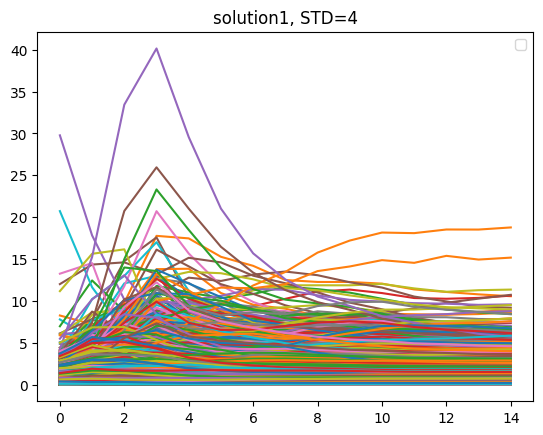

In [ ]:
plt.plot(solution1_std4)
plt.title("solution1, STD=4")
plt.show()

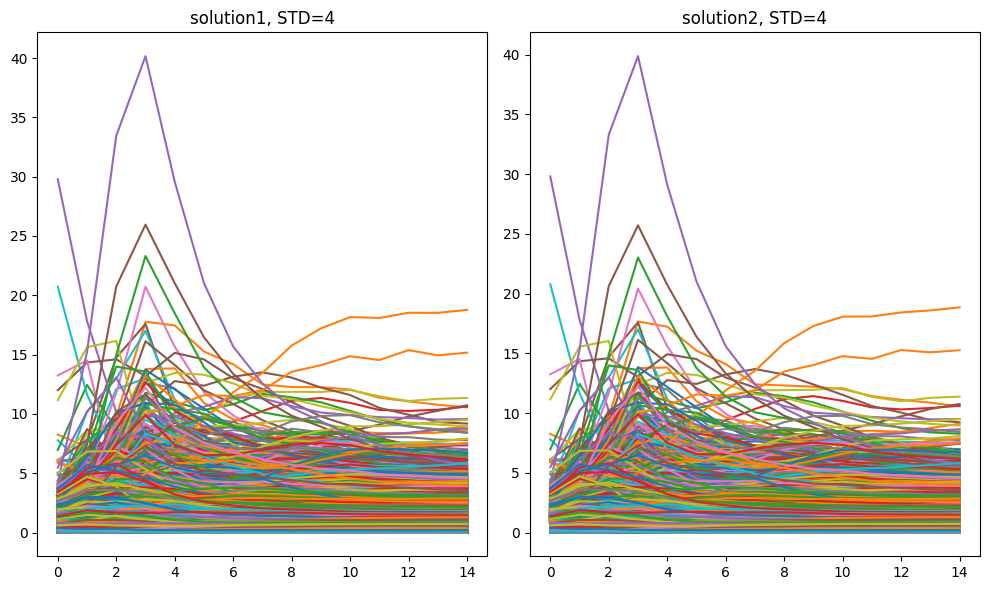

In [12]:
fig, axes = plt.subplots(1,2, figsize = (10,6))
# 1 figure with 2 axes, ie one axis per graph

axes[0].plot(solution1_std4)
axes[0].set_title("solution1, STD=4")

axes[1].plot(solution2_std4)
axes[1].set_title("solution2, STD=4")

plt.tight_layout()
plt.show()

In [13]:
def fano_factor(array, ax):
    avg = np.mean(array, axis = ax)
    var = np.var(array, axis = ax)
    return var / avg


In [14]:
fano_factor(solution1_std4, ax = 1)

array([0.37932202, 0.6047685 , 0.821471  , 0.9972809 , 0.8015535 ,
       0.6768288 , 0.62431216, 0.59600043, 0.5903678 , 0.58030677,
       0.5674926 , 0.5486287 , 0.5433269 , 0.53711396, 0.5373386 ],
      dtype=float32)

In [18]:
np.unique(fano_factor(solution1_std4, ax = 1) == fano_factor(solution2_std4, ax =1), return_counts = True)

(array([False]), array([15]))

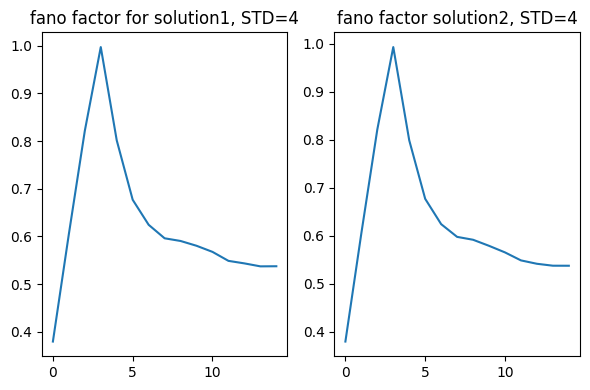

In [19]:
fig, axes = plt.subplots(1,2, figsize = (6,4))
# 1 figure with 2 axes, ie one axis per graph

axes[0].plot(fano_factor(solution1_std4, ax = 1))
axes[0].set_title("fano factor for solution1, STD=4")

axes[1].plot(fano_factor(solution2_std4, ax = 1))
axes[1].set_title("fano factor solution2, STD=4")

plt.tight_layout()
plt.show()

#### meeting with anton - June 26, 2025

Notes
- get one random neuron, plot 30 times
- need proof of concept first, 300 noise seeds 
- then increase std to 4 and 30
- plot histogram of neuron responses 
    - on top plot gaussian, poission distribution
- use p value that it is gaussian
- calculate slack values per neuron, plot those parameters on histogram (neurons on y axis) 

#### 3rd innermost loop work

Note that for now we are working with one frame, so third loop here loops once

In [6]:
frames = concatenate([
    full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
])

# add results to array and stack at end
noise_results = []

for i in range(2): # two noise seeds
    mean = 0
    sigma = 4
    size = (15,144,256) # changing to 500 milliseconds of noise (15 frames)
    noise = np.random.normal(loc = mean, scale = sigma, size = size)
    
    new_frames = (frames + noise).astype('uint8')
    
    stimuli = new_frames 

    sessions_scans = [[4,7],[5,6]] # just two scans for now

    for pair in sessions_scans:
        prediction1_std4 = visual_prediction(pair[0], pair[1], stimuli) 
        try:
            # ie here concat or np.stack?
            final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
        except NameError:
            final_concat1_std4 = prediction1_std4

    noise_results.append(final_concat1_std4)
    del final_concat1_std4

noise_stack = np.stack(noise_results, axis = 0)
    
"""
    try:
        #final_concat1_std4 = final_concat1_std4[np.newaxis,:,:]
        print(f"shape of final_concat2: {final_concat2_std4.shape}, final_concat1: {final_concat1_std4.shape} at round {i}")
        final_concat2_std4 = np.stack((final_concat2_std4, final_concat1_std4), axis = 0)
    except NameError:
        final_concat2_std4 = final_concat1_std4
        print("creating first final concat")
    del final_concat1_std4    
"""

'\n    try:\n        #final_concat1_std4 = final_concat1_std4[np.newaxis,:,:]\n        print(f"shape of final_concat2: {final_concat2_std4.shape}, final_concat1: {final_concat1_std4.shape} at round {i}")\n        final_concat2_std4 = np.stack((final_concat2_std4, final_concat1_std4), axis = 0)\n    except NameError:\n        final_concat2_std4 = final_concat1_std4\n        print("creating first final concat")\n    del final_concat1_std4    \n'

In [7]:
print(f"size of final noise_stack: ", noise_stack.shape)

size of final noise_stack:  (2, 15, 16085)


In [3]:
frames = concatenate([
    full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
])
images = [frames]

for image in images:

    noise_results = []

    for i in range(2): # two noise seeds
        mean = 0
        sigma = 4
        size = (15,144,256) # changing to 500 milliseconds of noise (15 frames)
        noise = np.random.normal(loc = mean, scale = sigma, size = size)
        
        new_frames = (image + noise).astype('uint8')

        sessions_scans = [[4,7],[5,6]] # just two scans for now

        for pair in sessions_scans:
            prediction1_std4 = visual_prediction(pair[0], pair[1], new_frames) 
            try:
                # ie here concat or np.stack?
                final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
            except NameError:
                final_concat1_std4 = prediction1_std4

        noise_results.append(final_concat1_std4)
        del final_concat1_std4
    noise_stack = np.stack(noise_results, axis = 0)


In [4]:
noise_stack.shape

(2, 15, 16085)

#### outermost loop

100 noise seeds with 15 frames took about 16 min to run with two sessions, note that this example is DYNAMIC NOISE

In [ ]:
# in order to minimize storage, pre allocate array sizes
noise_seeds = 100 
num_neurons = 16085 # dynamically pre allocate by summing. through scans.csv, for now just use constant
num_frames = 15 # again later dynamically calculate by summing through every object in frames

# keep dictionary with sigma results
sigma_dict = {'3': None,
              '40': None}

for sigma in [3, 40]:
    frames = concatenate([
        full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
    ])
    images = [frames]

    # results for each image we use as stimuli
    image_results = np.empty((len(images), noise_seeds, num_frames, num_neurons))

    for images_i in range(len(images)):

        # results for each time we add noise
        noise_results = np.empty((noise_seeds, num_frames, num_neurons)) 

        for noise_i in range(noise_seeds):
            mean = 0
            size = (15,144,256) # changing to 500 milliseconds of noise (15 frames)
            noise = np.random.normal(loc = mean, scale = sigma, size = size)
            
            image = images[images_i]
            new_frames = (image + noise).astype('uint8')

            sessions_scans = [[4,7],[5,6]] # just two scans for now

            for pair in sessions_scans:
                prediction1_std4 = visual_prediction(pair[0], pair[1], new_frames) 
                try:
                    # ie here concat or np.stack?
                    final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
                except NameError:
                    final_concat1_std4 = prediction1_std4

            #noise_results.append(final_concat1_std4)
            noise_results[noise_i] = final_concat1_std4
            del final_concat1_std4
        noise_stack = np.stack(noise_results, axis = 0)
        

        image_results[images_i] = noise_stack
        del noise_stack
    image_stack = np.stack(image_results, axis = 0)
    sigma_dict[str(sigma)] = image_stack

In [6]:
sigma_dict.keys()

dict_keys(['3', '40'])

Note that this code takes about 16 min. to run, and creates a dictionary sigma_dict with two sigmas as keys, and the items being the runs of the loop with those values 

#### Getting stats at end of loop

- calc. sum spike count over 90, shape should be (number images, 1000, number neurons)      
- calc. mean over 1000, shape should be (number images, number neurons)
- calc. var over 1000, shape should be (number images, number neurons)
- plot mean vs var
- calc. fano factor var over mean
- plot fano factor dist. as histogram

In [19]:
sigma_3 = sigma_dict['3']
sigma_40 = sigma_dict['40']

In [20]:
print(f"shape for 3: {sigma_3.shape}, shape for 40: {sigma_40.shape}")

shape for 3: (1, 100, 15, 16085), shape for 40: (1, 100, 15, 16085)


In [38]:
random_neurons = np.random.randint(0,num_neurons, size = 30)
print("random neurons\n",random_neurons)

random neurons
 [11316  5300 10192 11561  3000 15146 13174  8263  7810 14165  1662  6062
 13520  3466  9616 14197  3587  3770 15168  7117   876  6421 12524   579
 15428  1372  4398 10294  6090  2536]


#### test working with sigma 3 for dynamic noise

In [22]:
sigma_3.shape

(1, 100, 15, 16085)

In [23]:
sigma_3_sum = np.sum(sigma_3, axis = 2)
print("sigma 3 sum shape: ", sigma_3_sum.shape)

sigma 3 sum shape:  (1, 100, 16085)


In [24]:
sigma_3_mean = np.mean(sigma_3_sum, axis = 1)
print("sigma 3 mean shape: ", sigma_3_mean.shape)

sigma 3 mean shape:  (1, 16085)


In [25]:
sigma_3_var = np.var(sigma_3_sum, axis = 1)
print("sigma 3 var shape: ", sigma_3_var.shape)

sigma 3 var shape:  (1, 16085)


In [43]:
sigma_3_mean[:,random_neurons].shape

(1, 30)

In [49]:
random_3sigma = sigma_3_mean[:,random_neurons].flatten()

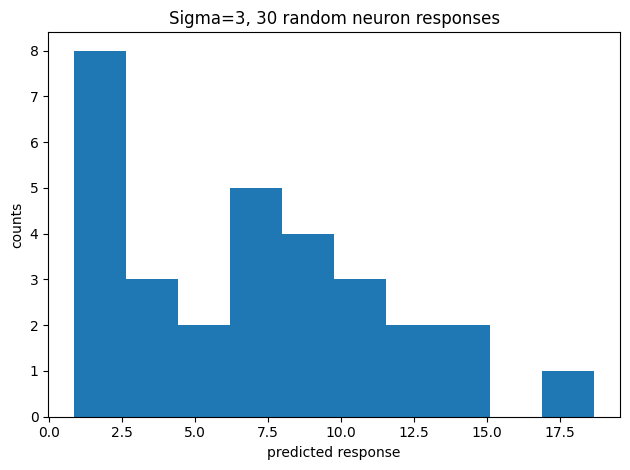

In [51]:
# taking the average predicted response for sum of all noise and frame instances 
plt.hist(random_3sigma, bins = 10)
plt.title("Sigma=3, 30 random neuron responses")
plt.ylabel("counts")
plt.xlabel("predicted response")
plt.tight_layout()
plt.show()

#### plots (final test_predict function here as well)

In [17]:
def generate_noise(noise_type, num_frames, mean, sigma):
    if noise_type == "constant":
        constant_noise_array = np.empty((num_frames, 144, 256))
        for i in range(num_frames):
            mean = 0
            noise = np.random.normal(loc = mean, scale = sigma, size = (144,256))
            # concat. 15 of these together
            constant_noise_array[i] = noise
        constant_noise = np.stack(constant_noise_array, axis = 0)
        return constant_noise
    
    elif noise_type == "dynamic": return np.random.normal(loc = mean, scale = 3, size = (num_frames, 144, 256))
    
    else: print("\n---Noise input not recognized, please try again---")

In [19]:
def test_predict_loop(noise_type, num_frames, mean, sigma):

# in order to minimize storage, pre allocate array sizes
    noise_seeds = 100 
    num_neurons = 7493 # dynamically pre allocate by summing. through scans.csv, for now just use constant
    num_frames = 15 # again later dynamically calculate by summing through every object in frames, should always be sum along first axis (axis = 0) of frames object


    frames = concatenate([
        full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
    ])
    images = [frames]

    # results for each image we use as stimuli
    image_results = np.empty((len(images), noise_seeds, num_frames, num_neurons))

    for images_i in range(len(images)):

        # results for each time we add noise
        noise_results = np.empty((noise_seeds, num_frames, num_neurons)) 

        for noise_i in range(noise_seeds):
                    
            # need to generate new noise every iteration 
            
            new_noise = generate_noise(noise_type, num_frames, mean, sigma)

            image = images[images_i]
            new_frames = (image + new_noise).astype('uint8')

            sessions_scans = [[4,7]] # just one scan

            # make predictions for one noise seed
            for pair in sessions_scans:
                prediction1_std4 = visual_prediction(pair[0], pair[1], new_frames) 
                try:
                    final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
                except NameError:
                    final_concat1_std4 = prediction1_std4

            noise_results[noise_i] = final_concat1_std4
            del final_concat1_std4
        noise_stack = np.stack(noise_results, axis = 0) # generate final object/stack of predictions after all noise seeds
        

        image_results[images_i] = noise_stack
        del noise_stack
    image_stack = np.stack(image_results, axis = 0)

    return image_stack

In [5]:
sigma = 3

# dynamic noise
mean = 0
size = (15,144,256) # changing to 500 milliseconds of noise (15 frames)
dynamic_noise = np.random.normal(loc = mean, scale = sigma, size = size)

# constant noise
num_frames = 15
constant_noise_array = np.empty((num_frames, 144, 256))

for i in range(num_frames):
    mean = 0
    size = (144,256)
    noise = np.random.normal(loc = mean, scale = sigma, size = size)
    # concat. 15 of these together
    constant_noise_array[i] = noise
constant_noise = np.stack(constant_noise_array, axis = 0)


In [20]:
dynamic_3 = test_predict_loop("dynamic", 15, 0, 3)

In [21]:
constant_3 = test_predict_loop("constant", 15, 0, 3)

In [22]:
dynamic_40 = test_predict_loop("dynamic", 15, 0, 40)
constant_40 = test_predict_loop("constant", 15, 0, 40)

In [14]:
constant_40.shape

(1, 100, 15, 7493)

Constant_40 plots

In [15]:
constant_40_3d = constant_40[0]
constant_40_3d.shape

(100, 15, 7493)

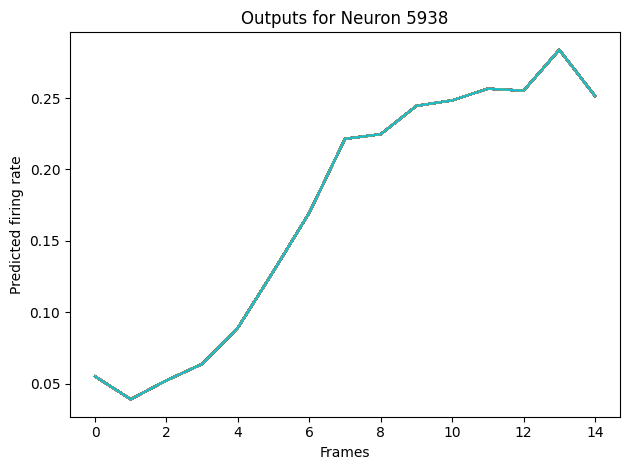

In [47]:
neuron = 5938

test_plot = constant_40_3d[:,:,neuron]

plt.plot(test_plot.T)
plt.title(f"Outputs for Neuron {neuron}")
plt.xlabel("Frames")
plt.ylabel("Predicted firing rate")
plt.tight_layout()
plt.show()

#### final plots

In [15]:
def plot_30random(array, title):
    array = array[0]
    fig, axes = plt.subplots(5,6, figsize = (20,6))

    neurons = np.random.randint(0, 7493, size = 30)

    for id, neuron in enumerate(neurons):
        row = id // 6
        col = id % 6
        ax = axes[row, col]
        plot = np.sum(array[:,:,neuron], axis = 1).flatten()
        ax.hist(plot)

    fig.suptitle(f"Neuron outputs: {title}")
    fig.supxlabel('predicted firing rate')
    fig.supylabel('counts')
    plt.tight_layout()
    plt.show()

    print("for the following neurons: ",neurons)

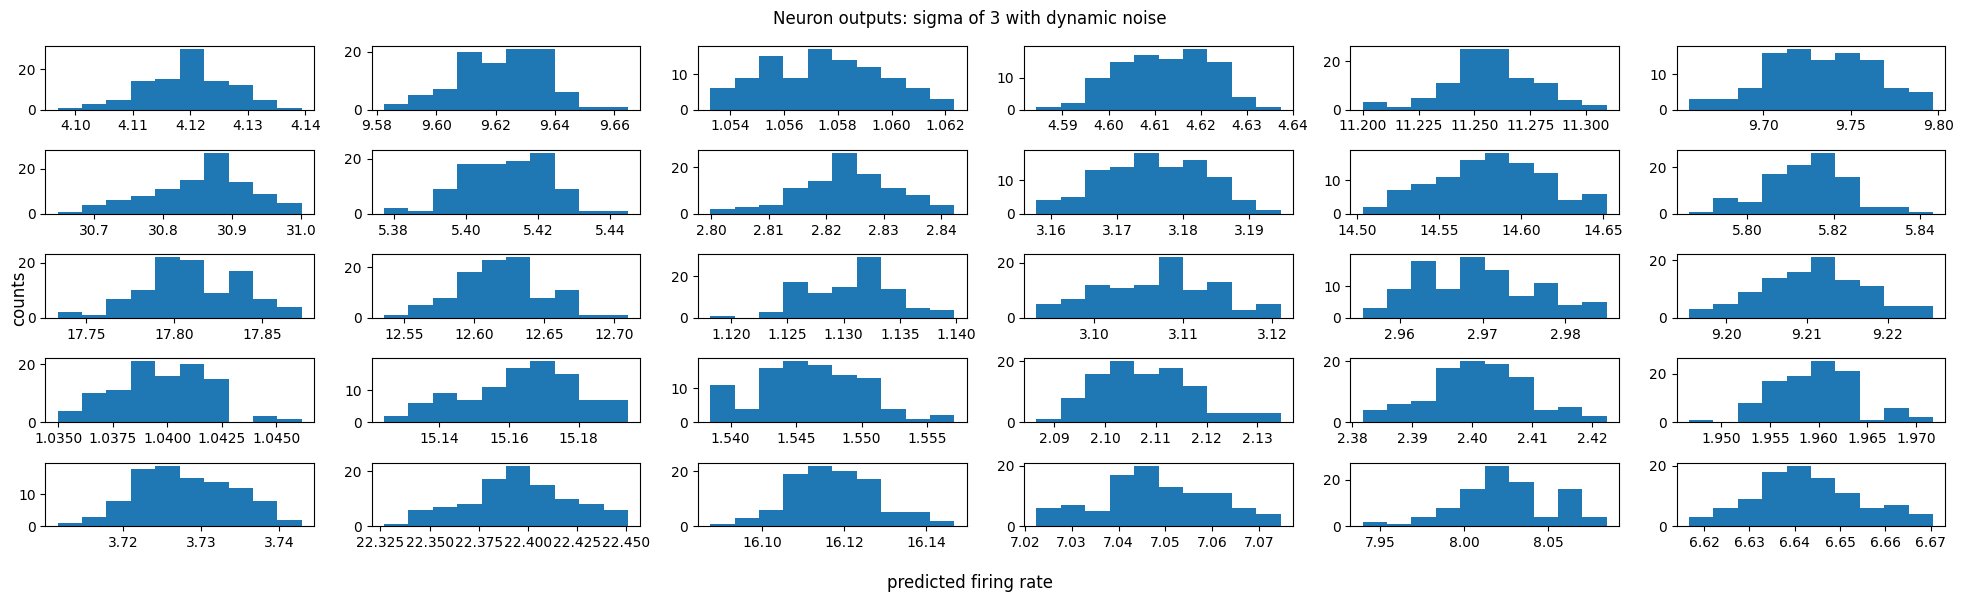

for the following neurons:  [4145 7339 7336  403 2993 5573 3736 4984 2719 5363  262 6713 1006 5148
 4378  632 6773 6964  212 7328 4841 4413 5092 5589 3770 3404 2608 5800
 3697  269]


In [23]:
plot_30random(dynamic_3, "sigma of 3 with dynamic noise")

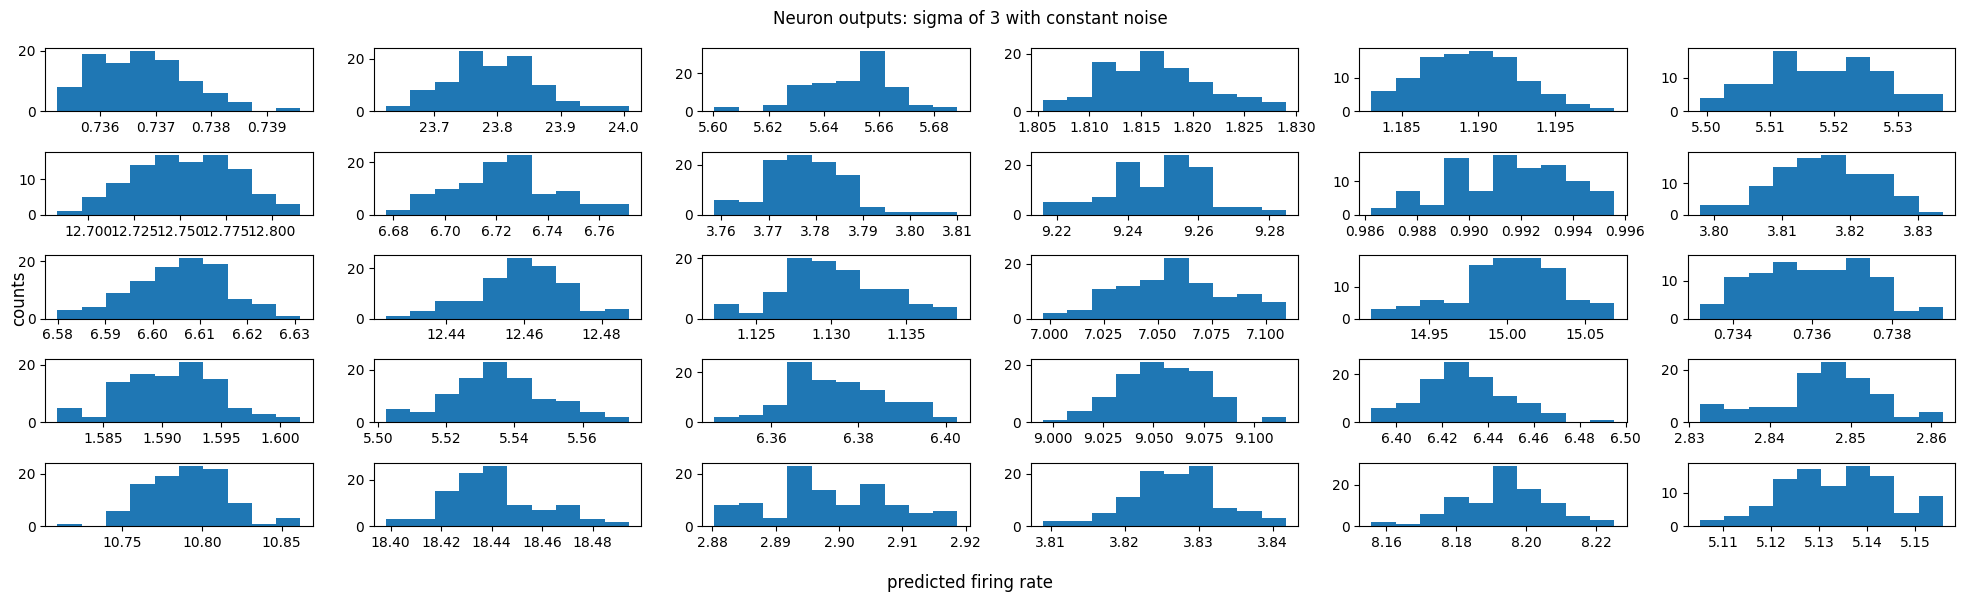

for the following neurons:  [  28 4582 4212 5373 6665 4864 3301 2528 1405 7474 1827 3831 4819 3312
 2619 1215 5122 1621 6216 6612 6910  968 5368 4764 3720 5476 1672 7378
 6792 1833]


In [24]:
plot_30random(constant_3, "sigma of 3 with constant noise")

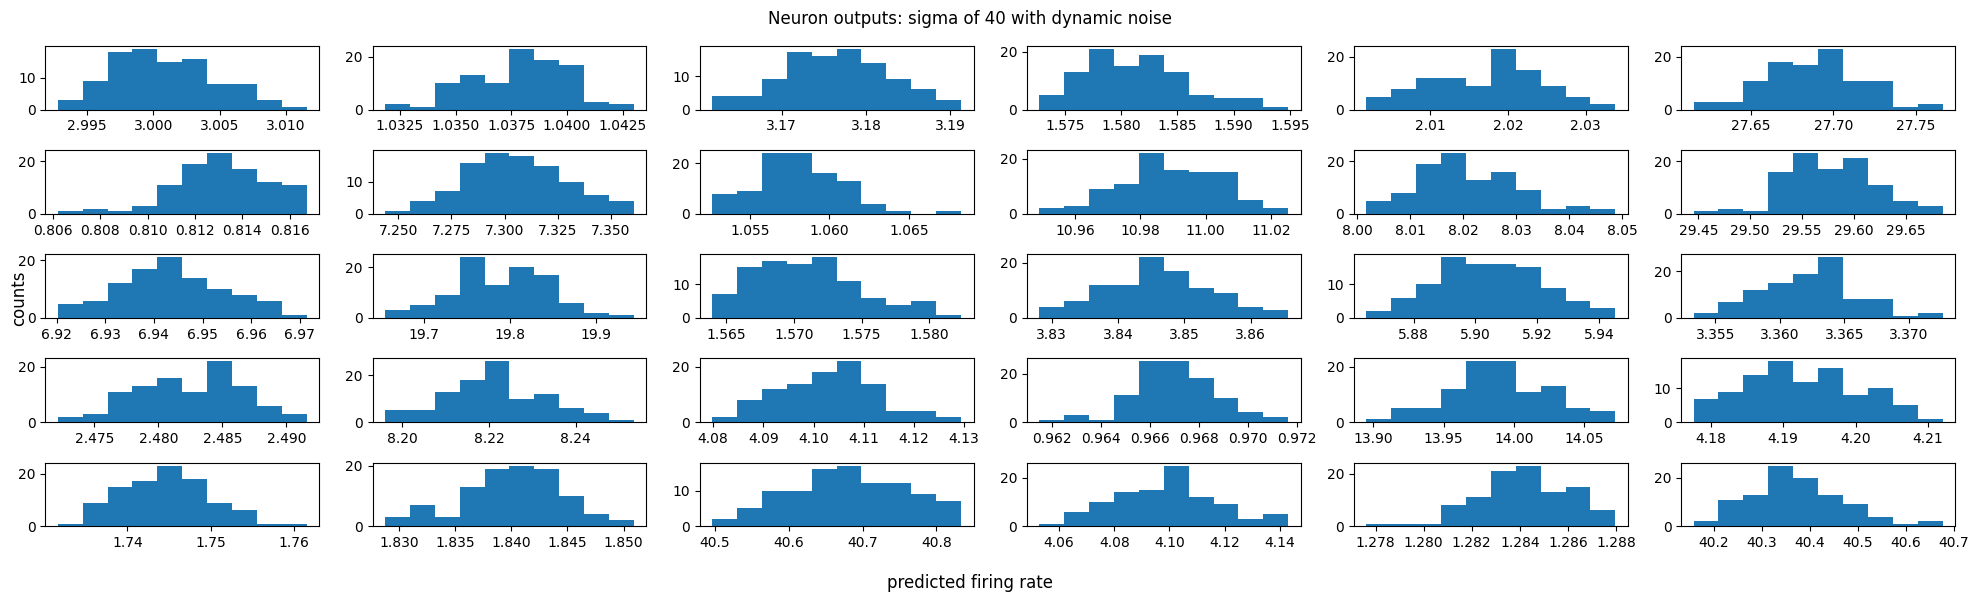

for the following neurons:  [3486  173 2828  945 4499 3425 2143 4003 4355 7452 5982 2349 3655 6242
 3415 3504 1225 6465 6340 3076 1048  485 3258 3265 1414 6135 7367 1799
 6333 1145]


In [25]:
plot_30random(dynamic_40, "sigma of 40 with dynamic noise")

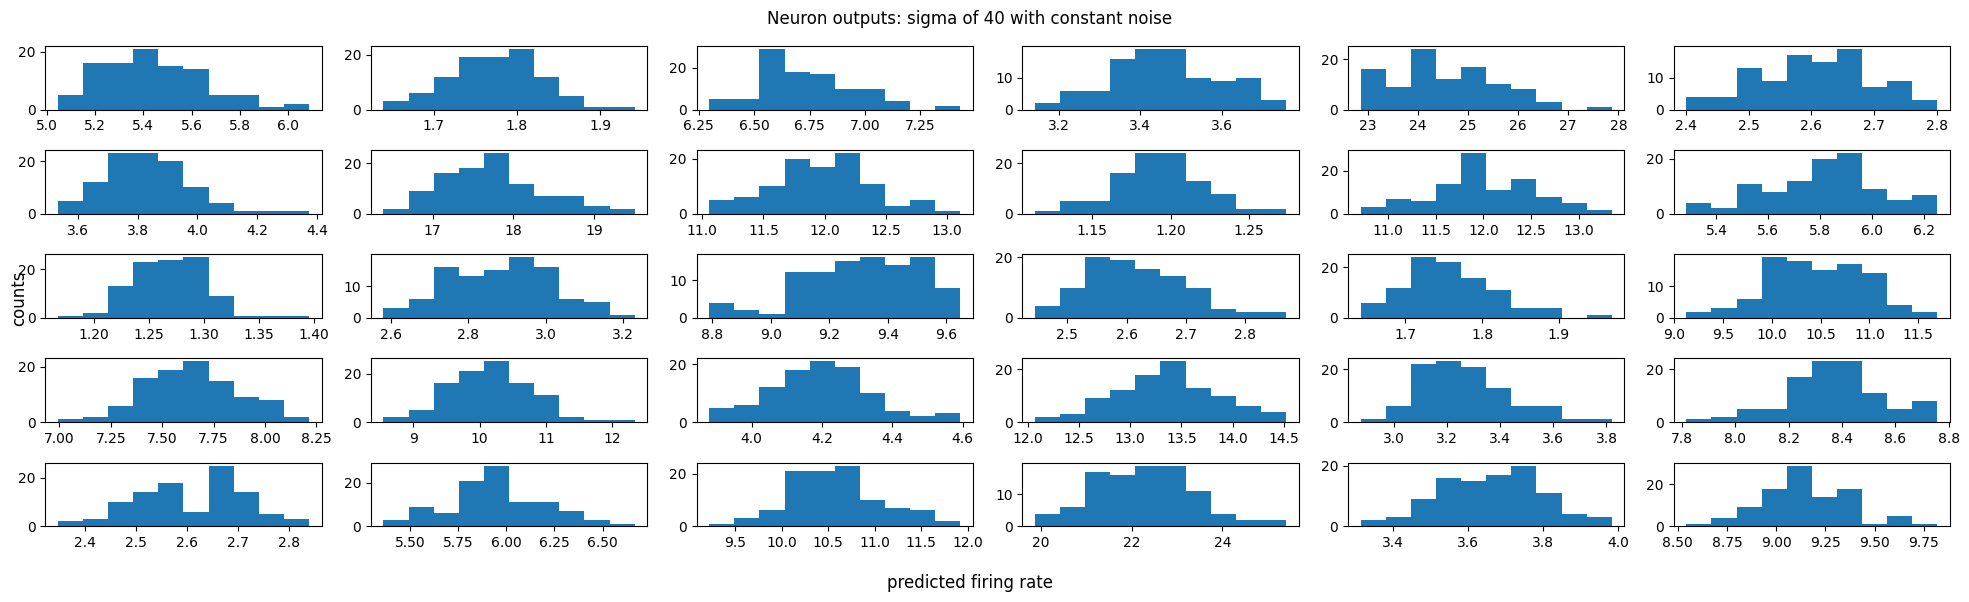

for the following neurons:  [3179 3747 6049  883 1735  721 6194 6531 3537 5836 2695 6807 7323 4928
 5599 5219 6880 3430 6242 4911 6228 6575 6255 6869  188 1091 5679  938
 2272 5962]


In [26]:
plot_30random(constant_40, "sigma of 40 with constant noise")